# Demographic Segmentation – Clustering
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

This notebook focuses on customer segmentation from a demographic perspective. Using geographic and socioeconomic variables, we prepare the data for clustering by inspecting distributions, handling potential outliers, encoding selected demographic attributes, and scaling numerical features. The goal is to create a clean and consistent dataset that can be used in later stages to identify meaningful customer segments based on demographic characteristics.

<a class="anchor" id='toc'></a> 
<div class="alert alert-block alert-info">

## **Index**<br>

[**Imports**](#1st-bullet)<br>

[**Data Preposessing**](#2nd-bullet)<br>

    
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, r2_score
from kmodes.kprototypes import KPrototypes

In [2]:
df_AIAI_Master = pd.read_csv(
    'DM_AIAI_MasterCustomerDB.csv',
    index_col=0,
    parse_dates=['EnrollmentDateOpening', 'CancellationDate']
)

In [3]:
df_demo = df_AIAI_Master[[
    'Latitude',
    'Longitude',
    'Income',
    'Gender',
    'Marital Status'
]].copy()

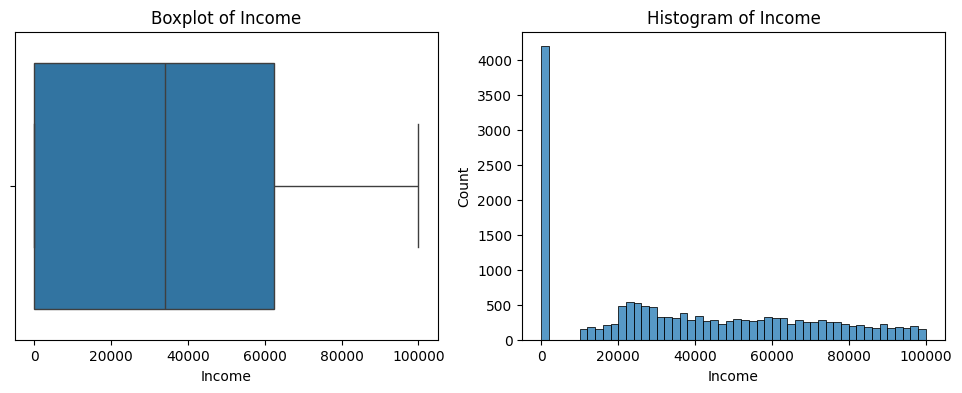

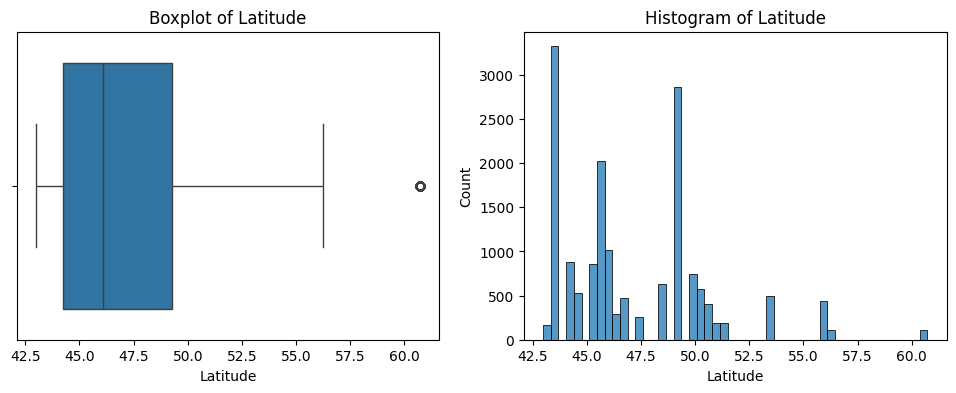

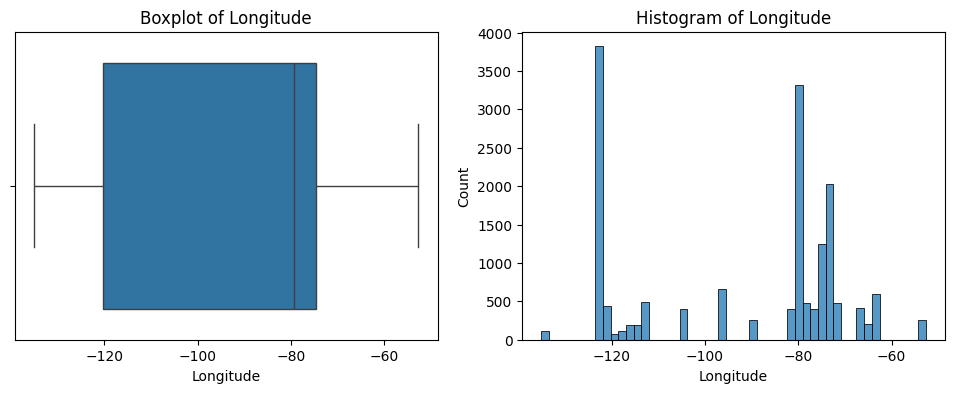

In [4]:
num_vars = ['Income', 'Latitude', 'Longitude']

for var in num_vars:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x=df_demo[var], ax=ax[0])
    sns.histplot(df_demo[var], bins=50, ax=ax[1])
    ax[0].set_title(f'Boxplot of {var}')
    ax[1].set_title(f'Histogram of {var}')
    plt.show()

In [5]:
df_demo_ceiled = df_demo.copy()

for var in ['Income', 'Latitude', 'Longitude']:
    Q1 = df_demo_ceiled[var].quantile(0.25)
    Q3 = df_demo_ceiled[var].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 3 * IQR

    df_demo_ceiled[var] = np.where(
        df_demo_ceiled[var] > upper_bound,
        upper_bound,
        df_demo_ceiled[var]
    )

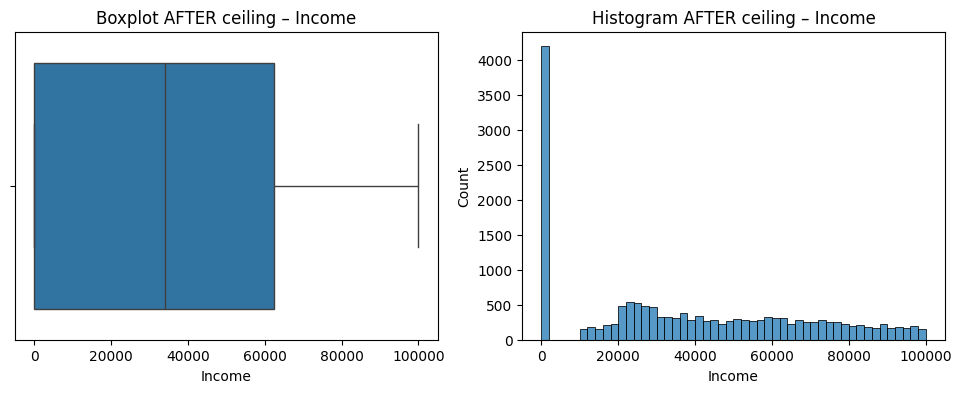

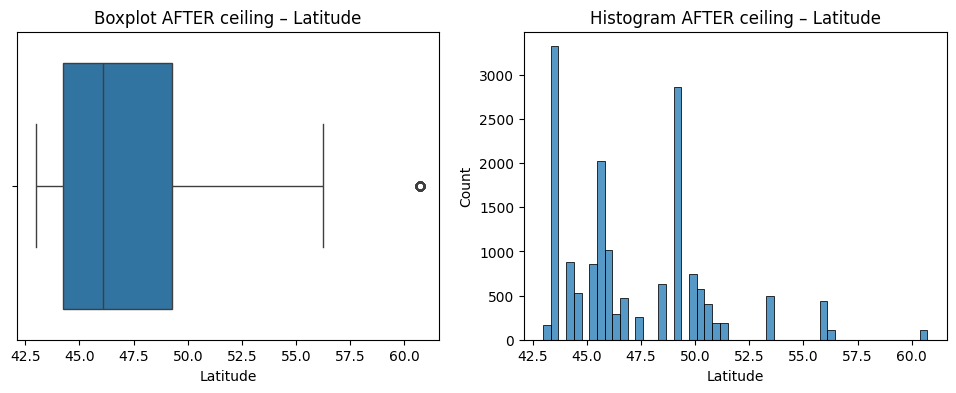

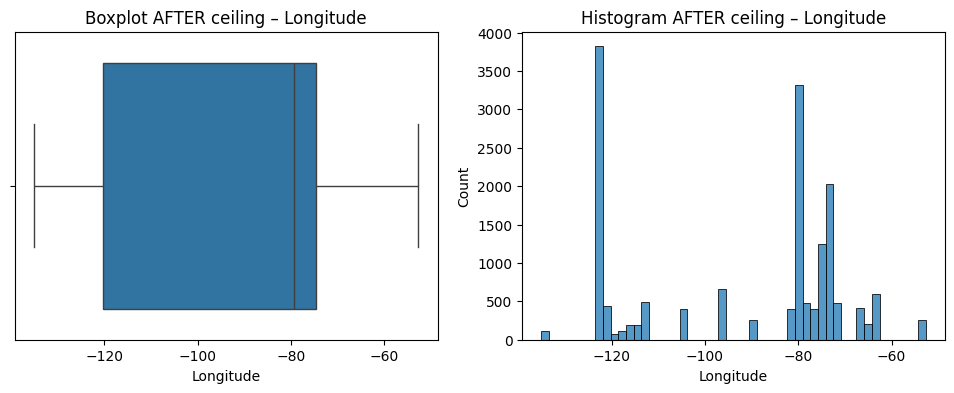

In [6]:
for var in ['Income', 'Latitude', 'Longitude']:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x=df_demo_ceiled[var], ax=ax[0])
    sns.histplot(df_demo_ceiled[var], bins=50, ax=ax[1])
    ax[0].set_title(f'Boxplot AFTER ceiling – {var}')
    ax[1].set_title(f'Histogram AFTER ceiling – {var}')
    plt.show()

After comparing the boxplots and histograms before and after applying the 3×IQR ceiling, no meaningful changes were observed. This shows that income and geographic variables do not contain extreme outliers and are already well behaved.

In [7]:
X_demo = df_demo_ceiled[['Latitude', 'Longitude', 'Income']]

scaler = MinMaxScaler()
X_demo_scaled = scaler.fit_transform(X_demo)

K-means clustering will be performed using only continuous demographic variables (Income, Latitude, Longitude). Gender and marital status will be incorporated later during cluster profiling to characterize the segments.

<a class="anchor" id="3rd-bullet"></a>
## Demographic Clustering – K-Means

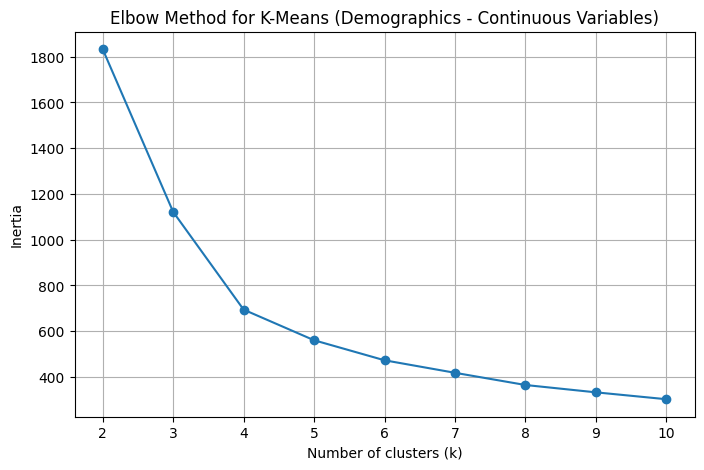

In [8]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_demo_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means (Demographics - Continuous Variables)')
plt.grid(True)
plt.show()

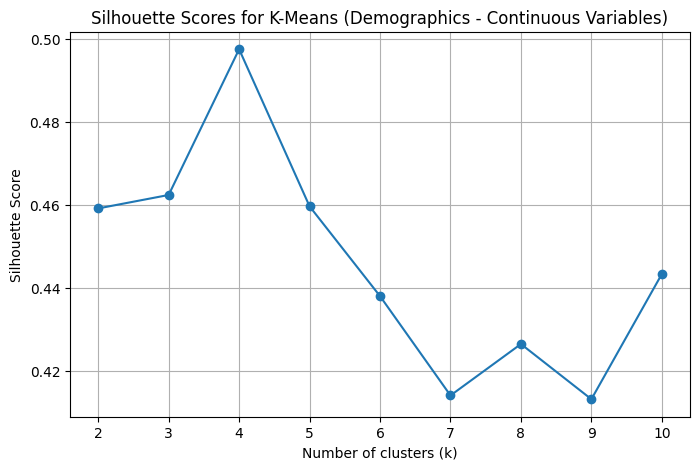

k=2: 0.4592
k=3: 0.4624
k=4: 0.4975
k=5: 0.4597
k=6: 0.4381
k=7: 0.4142
k=8: 0.4265
k=9: 0.4133
k=10: 0.4434


In [9]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_demo_scaled)
    score = silhouette_score(X_demo_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means (Demographics - Continuous Variables)')
plt.grid(True)
plt.show()

# Print scores for clarity
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")

Both the elbow method and silhouette analysis indicate that k=4 provides the optimal clustering solution. The elbow plot shows diminishing returns after k=4, and the silhouette score reaches its maximum at this value (0.4975), indicating the best balance between cluster cohesion and separation.

### Final K-Means Model (k = 4)

In [10]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
demo_clusters = kmeans_final.fit_predict(X_demo_scaled)

df_demo_ceiled['Cluster'] = demo_clusters

In [11]:
cluster_counts = df_demo_ceiled['Cluster'].value_counts().sort_index()
cluster_counts

Cluster
0    5793
1    2762
2    3735
3    4282
Name: count, dtype: int64

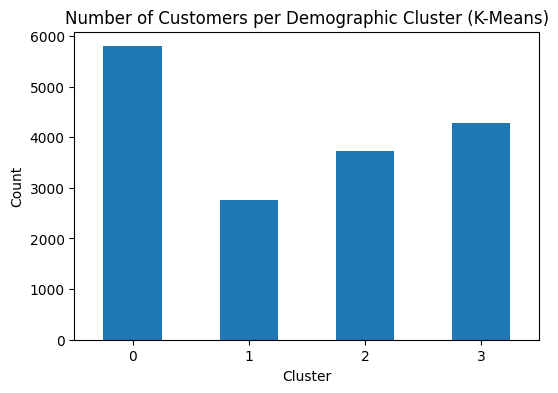

In [12]:
cluster_counts.plot(kind='bar', figsize=(6,4))
plt.title('Number of Customers per Demographic Cluster (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

The four clusters show reasonable size distribution, with no degenerate or overly small clusters, indicating a stable segmentation solution.

In [13]:
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=['Latitude', 'Longitude', 'Income']
)
centroids_df['Cluster'] = centroids_df.index
centroids_df

,Latitude,Longitude,Income,Cluster
0,44.955855,-75.116649,15282.278536,0
1,50.611173,-118.012702,68330.728525,1
2,50.638023,-117.906328,15108.109684,2
3,44.938646,-74.845818,68149.278245,3


In [14]:
# Cluster profiling with all demographic variables
cluster_profile = df_demo_ceiled.groupby('Cluster')[['Income', 'Latitude', 'Longitude']].mean()
print("\nCluster Profiles (Mean Values):")
print(cluster_profile)

# Add gender and marital status distributions
print("\n" + "="*60)
print("Gender Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster'], df_demo_ceiled['Gender'], normalize='index') * 100)

print("\n" + "="*60)
print("Marital Status Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster'], df_demo_ceiled['Marital Status'], normalize='index') * 100)


Cluster Profiles (Mean Values):
               Income   Latitude   Longitude
Cluster                                     
0        15291.401174  44.955724  -75.117118
1        68301.873642  50.611912 -118.011487
2        15086.698527  50.637498 -117.907141
3        68161.629145  44.938814  -74.845057

Gender Distribution by Cluster:
Gender      female       male
Cluster                      
0        49.594338  50.405662
1        51.701665  48.298335
2        50.923695  49.076305
3        49.789818  50.210182

Marital Status Distribution by Cluster:
Marital Status   Divorced    Married     Single
Cluster                                        
0               14.690143  50.819955  34.489902
1               15.242578  68.139030  16.618392
2               14.591700  51.030790  34.377510
3               15.623540  68.028958  16.347501


The four demographic clusters reveal distinct segments based primarily on **income and geographic location**:

- **Clusters 0 and 2**: Low-income segments (about $15,000 annual income) located in eastern and western regions respectively
- **Clusters 1 and 3**: High-income segments (about $68,000 annual income) also distributed across eastern and western regions

Gender distribution is relatively balanced across all clusters (49-52% female). However, marital status shows variation: high-income clusters have notably higher marriage rates (~68%) compared to low-income clusters (~51%), suggesting household composition correlates with income levels. Geographic location creates regional variants within income tiers, indicating both income and geography drive the segmentation.

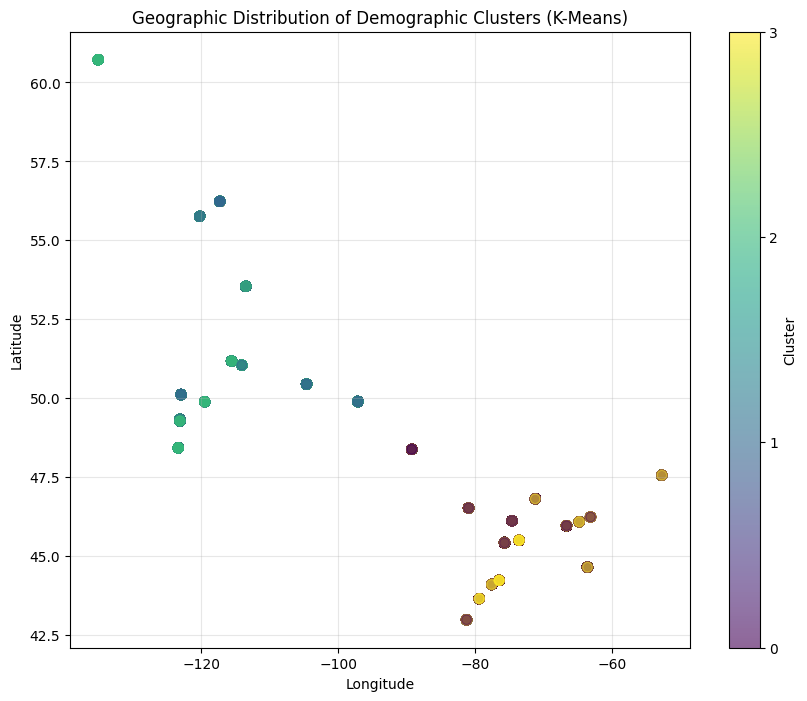

In [15]:
# Geographic visualization of clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_demo_ceiled['Longitude'], 
    df_demo_ceiled['Latitude'],
    c=df_demo_ceiled['Cluster'],
    cmap='viridis',
    alpha=0.6,
    s=50
)
plt.colorbar(scatter, label='Cluster', ticks=[0, 1, 2, 3])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Demographic Clusters (K-Means)')
plt.grid(True, alpha=0.3)
plt.show()

The map displays customers colored by their demographic cluster assignment:

- **Cluster 0** (purple): Low income, eastern region (around Long -75°, Lat 45°)
- **Cluster 1** (blue): High income, western region (around Long -118°, Lat 51°)  
- **Cluster 2** (green): Low income, western region (around Long -118°, Lat 50°)
- **Cluster 3** (yellow): High income, eastern region (around Long -75°, Lat 45°)

The geographic visualization shows two distinct regional clusters. A western group (Clusters 1 and 2, around longitude -120°) and an eastern group (Clusters 0 and 3, around longitude -70°). Within each geographic region, customers are further segmented by income level, with high-income and low-income clusters occupying the same geographic areas.

c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Conside

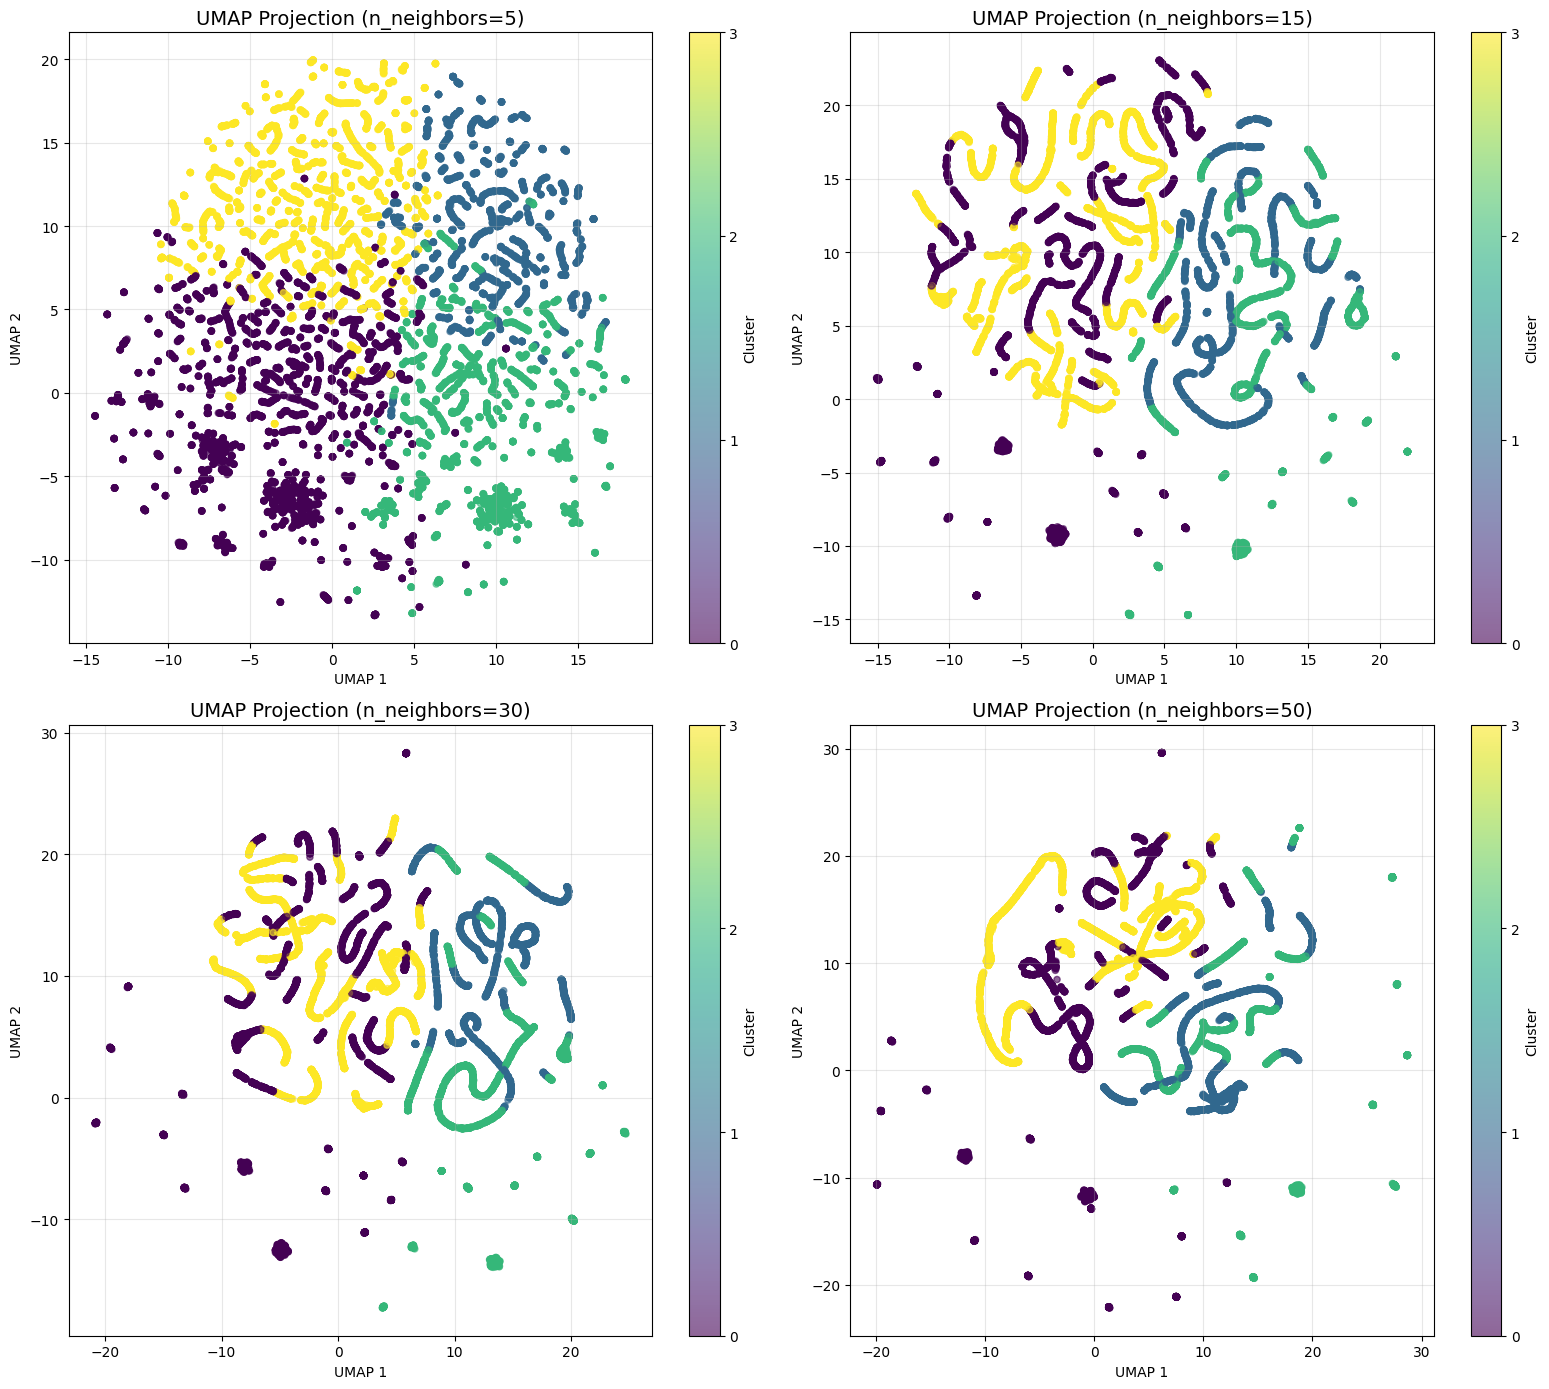

In [16]:
# Test different n_neighbors values
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
n_neighbors_values = [5, 15, 30, 50]

for idx, n_neighbors in enumerate(n_neighbors_values):
    ax = axes[idx // 2, idx % 2]
    
    # Create UMAP
    reducer = umap.UMAP(n_neighbors=n_neighbors, random_state=42)
    embedding = reducer.fit_transform(X_demo_scaled)
    
    # Plot
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=df_demo_ceiled['Cluster'],
        cmap='viridis',
        alpha=0.6,
        s=20
    )
    ax.set_title(f'UMAP Projection (n_neighbors={n_neighbors})', fontsize=14)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.grid(True, alpha=0.3)
    fig.colorbar(scatter, ax=ax, label='Cluster', ticks=[0, 1, 2, 3])

plt.tight_layout()
plt.show()

Different n_neighbors values were tested to optimize the UMAP visualization of demographic clusters. Lower values (n_neighbors=5) preserve more local structure, showing tighter individual cluster formations. As n_neighbors increases (15, 30, 50), the projection emphasizes global structure, revealing how clusters relate to each other in the overall demographic space. All projections confirm that the four clusters are reasonably well-separated, with n_neighbors=15 providing a good balance between local detail and global cluster relationships. The UMAP visualizations validate that the K-means solution has captured distinct demographic segments based on income and geographic patterns.

In [17]:
print("Clustering Quality Metrics")
print("=" * 50)

# Silhouette Score
sil_score = silhouette_score(X_demo_scaled, demo_clusters)
print(f"Silhouette Score: {sil_score:.4f}")

# Calinski-Harabasz Score
ch_score = calinski_harabasz_score(X_demo_scaled, demo_clusters)
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

# Davies-Bouldin Score
db_score = davies_bouldin_score(X_demo_scaled, demo_clusters)
print(f"Davies-Bouldin Score: {db_score:.4f}")

Clustering Quality Metrics
Silhouette Score: 0.4975
Calinski-Harabasz Score: 20818.1160
Davies-Bouldin Score: 0.7268


In [ ]:
print("\nR² Score per Variable (Variance Explained by Clustering)")
print("=" * 50)

for var in ['Income', 'Latitude', 'Longitude']:
    cluster_means = df_demo_ceiled.groupby('Cluster')[var].transform('mean')
    r2 = r2_score(df_demo_ceiled[var], cluster_means)
    print(f"{var:12s}: {r2:.4f}")



R² Score per Variable (Variance Explained by Clustering)
Income      : 0.7451
Latitude    : 0.7033
Longitude   : 0.8889


The clustering quality metrics indicate a strong demographic segmentation. The Silhouette Score of 0.50 demonstrates good cluster cohesion and separation, while the Calinski-Harabasz score of 20,818 reflects well-defined between-cluster variance. The Davies-Bouldin score of 0.73 indicates good cluster separation with minimal overlap.

The R² scores reveal that clustering effectively explains variance across all demographic variables: 89% for longitude, 74% for income, and 70% for latitude. These high R² values confirm that the four clusters successfully capture the primary patterns in customer demographics, with geographic location being the strongest differentiator, followed closely by income level. This validates the use of continuous variables for demographic clustering.

## Demographic Clustering – K-Prototypes

In [29]:
# Prepare data: numerical + categorical
X_numerical = df_demo_ceiled[['Latitude', 'Longitude', 'Income']].values
X_categorical = df_demo_ceiled[['Gender', 'Marital Status']].values

# Scale numerical features (categorical features don't need scaling)
scaler_kproto = MinMaxScaler()
X_num_scaled = scaler_kproto.fit_transform(X_numerical)

# Combine into single array
X_kproto = np.column_stack([X_num_scaled, X_categorical])

print("K-Prototypes data shape:", X_kproto.shape)
print("Numerical features (scaled): Latitude, Longitude, Income")
print("Categorical features: Gender, Marital Status")

K-Prototypes data shape: (16572, 5)
Numerical features (scaled): Latitude, Longitude, Income
Categorical features: Gender, Marital Status


k=2: cost=3724.17
k=3: cost=2937.77
k=4: cost=2483.16
k=5: cost=2110.83
k=6: cost=1875.01
k=7: cost=1698.95
k=8: cost=1553.07
k=9: cost=1408.36
k=10: cost=1323.06


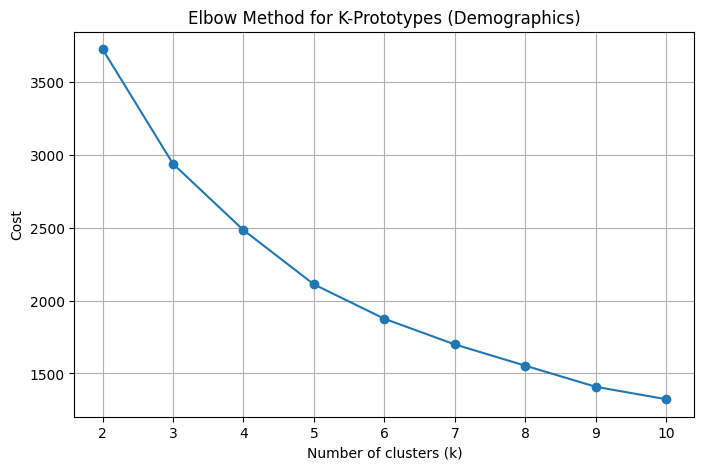

In [20]:
# Test different k values for K-Prototypes
cost = []
K_range = range(2, 11)

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=42, verbose=0)
    kproto.fit(X_kproto, categorical=[3, 4])  # columns 3 and 4 are categorical
    cost.append(kproto.cost_)
    print(f"k={k}: cost={kproto.cost_:.2f}")

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, cost, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Cost')
plt.title('Elbow Method for K-Prototypes (Demographics)')
plt.grid(True)
plt.show()

k=2: 0.4482
k=3: 0.3524
k=4: 0.4014
k=5: 0.2690
k=6: 0.1970
k=7: 0.0921
k=8: 0.0385
k=9: 0.0512
k=10: 0.0152


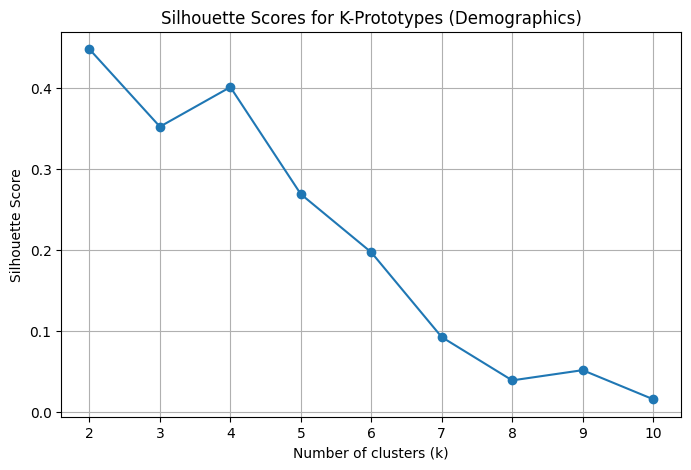

In [21]:
# Calculate silhouette scores for K-Prototypes
silhouette_scores_kproto = []

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=42, verbose=0)
    clusters = kproto.fit_predict(X_kproto, categorical=[3, 4])
    
    # For silhouette, we use only the numerical features (scaled)
    score = silhouette_score(X_num_scaled, clusters)
    silhouette_scores_kproto.append(score)
    print(f"k={k}: {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores_kproto, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Prototypes (Demographics)')
plt.grid(True)
plt.show()

The elbow method shows diminishing returns after k=4, while the silhouette analysis indicates k=2 or k=4 as reasonable choices. To enable direct comparison with the K-means results, we select k=4 for K-Prototypes, which balances cluster granularity with interpretability.


Cluster sizes:
Cluster_KProto
0    2879
1    3433
2    4680
3    5580
Name: count, dtype: int64


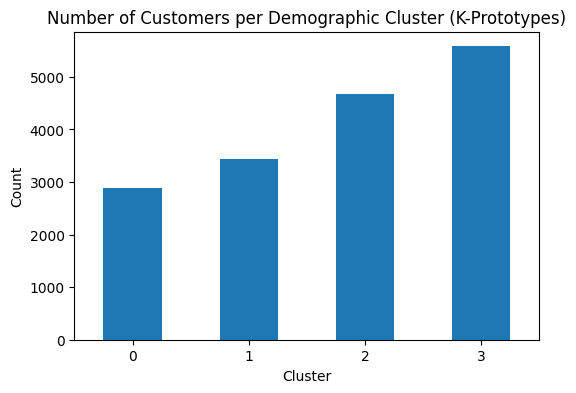

In [23]:
# K-Prototypes model with k=4
kproto_final = KPrototypes(n_clusters=4, init='Huang', random_state=42, verbose=0)
clusters_kproto = kproto_final.fit_predict(X_kproto, categorical=[3, 4])

df_demo_ceiled['Cluster_KProto'] = clusters_kproto

# Cluster size distribution
cluster_counts_kproto = df_demo_ceiled['Cluster_KProto'].value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_counts_kproto)

# Visualize cluster sizes
cluster_counts_kproto.plot(kind='bar', figsize=(6,4))
plt.title('Number of Customers per Demographic Cluster (K-Prototypes)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [24]:
# Cluster profiling - numerical variables
cluster_profile_kproto = df_demo_ceiled.groupby('Cluster_KProto')[['Income', 'Latitude', 'Longitude']].mean()
print("K-Prototypes Cluster Profiles (Numerical Variables):")
print(cluster_profile_kproto)

# Cluster profiling - categorical variables
print("\n" + "="*60)
print("Gender Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster_KProto'], df_demo_ceiled['Gender'], normalize='index') * 100)

print("\n" + "="*60)
print("Marital Status Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster_KProto'], df_demo_ceiled['Marital Status'], normalize='index') * 100)

K-Prototypes Cluster Profiles (Numerical Variables):
                      Income   Latitude   Longitude
Cluster_KProto                                     
0               64812.592914  50.644347 -118.396746
1               15220.348675  50.607507 -118.472150
2               64500.539103  45.033589  -75.247999
3               15186.441219  45.068069  -75.668663

Gender Distribution by Cluster:
Gender             female       male
Cluster_KProto                      
0               67.627648  32.372352
1               36.294786  63.705214
2               35.085470  64.914530
3               62.724014  37.275986

Marital Status Distribution by Cluster:
Marital Status   Divorced    Married     Single
Cluster_KProto                                 
0               14.935742  68.669677  16.394581
1               14.797553  49.868919  35.333528
2               15.982906  68.226496  15.790598
3               14.336918  49.516129  36.146953


The K-Prototypes clustering reveals four distinct demographic segments combining income, geography, and household characteristics:

- **Cluster 0**: High-income, western region, predominantly female (68%), highly married (69%)
- **Cluster 1**: Low-income, western region, predominantly male (64%), evenly split on marital status (50%)
- **Cluster 2**: High-income, eastern region, predominantly male (65%), highly married (68%)
- **Cluster 3**: Low-income, eastern region, predominantly female (63%), evenly split on marital status (50%)

Unlike K-means which focused purely on income and geography, K-Prototypes successfully incorporates gender and marital status into the segmentation. The clusters show clear patterns where high-income segments have higher marriage rates (68-69%) and exhibit gender skew, while low-income segments are more balanced in marital status (about 50%) but still show gender preferences. Geography continues to play a role, with distinct eastern and western regional variants for each income-gender-marital combination.

In [26]:
print("Clustering Quality Metrics (K-Prototypes)")
print("=" * 50)

# Silhouette Score (using only numerical features)
sil_score_kproto = silhouette_score(X_num_scaled, clusters_kproto)
print(f"Silhouette Score: {sil_score_kproto:.4f}")

# Calinski-Harabasz Score
ch_score_kproto = calinski_harabasz_score(X_num_scaled, clusters_kproto)
print(f"Calinski-Harabasz Score: {ch_score_kproto:.4f}")

# Davies-Bouldin Score
db_score_kproto = davies_bouldin_score(X_num_scaled, clusters_kproto)
print(f"Davies-Bouldin Score: {db_score_kproto:.4f}")

Clustering Quality Metrics (K-Prototypes)
Silhouette Score: 0.4014
Calinski-Harabasz Score: 15790.7703
Davies-Bouldin Score: 0.8478


The K-Prototypes clustering quality metrics show good performance across multiple measures. The silhouette score of 0.40 indicates reasonable cluster separation and cohesion. The Calinski-Harabasz score of 15,791 reflects well-defined between-cluster variance, while the Davies-Bouldin score of 0.85 suggests acceptable cluster separation with moderate overlap.

In [27]:
print("\nR² Score per Variable (Variance Explained by K-Prototypes)")
print("=" * 50)

for var in ['Income', 'Latitude', 'Longitude']:
    cluster_means = df_demo_ceiled.groupby('Cluster_KProto')[var].transform('mean')
    r2 = r2_score(df_demo_ceiled[var], cluster_means)
    print(f"{var:12s}: {r2:.4f}")


R² Score per Variable (Variance Explained by K-Prototypes)
Income      : 0.6575
Latitude    : 0.6701
Longitude   : 0.8800


The R² scores demonstrate that K-Prototypes effectively captures variance in the demographic variables, with longitude explaining 88% of variance, latitude 67%, and income 66%. These results confirm that K-Prototypes successfully segments customers using both continuous and categorical variables, creating distinct demographic groups that combine income, geography, gender, and marital status characteristics.

## Comparison between K-Means and K-Prototypes

In [28]:
print("=" * 70)
print("COMPARISON: K-Means vs K-Prototypes")
print("=" * 70)
print(f"{'Metric':<30} {'K-Means':<20} {'K-Prototypes':<20}")
print("=" * 70)

# Silhouette scores
print(f"{'Silhouette Score':<30} {0.4975:<20.4f} {sil_score_kproto:<20.4f}")

# Calinski-Harabasz
print(f"{'Calinski-Harabasz Score':<30} {20818.1160:<20.2f} {ch_score_kproto:<20.2f}")

# Davies-Bouldin
print(f"{'Davies-Bouldin Score':<30} {0.7268:<20.4f} {db_score_kproto:<20.4f}")

print("=" * 70)
print("\nR² Scores Comparison")
print("=" * 70)

# R² comparison
r2_kmeans = {'Income': 0.7451, 'Latitude': 0.7033, 'Longitude': 0.8889}
r2_kproto = {'Income': 0.6575, 'Latitude': 0.6701, 'Longitude': 0.8800}

for var in ['Income', 'Latitude', 'Longitude']:
    print(f"{var:<30} {r2_kmeans[var]:<20.4f} {r2_kproto[var]:<20.4f}")

print("=" * 70)

COMPARISON: K-Means vs K-Prototypes
Metric                         K-Means              K-Prototypes        
Silhouette Score               0.4975               0.4014              
Calinski-Harabasz Score        20818.12             15790.77            
Davies-Bouldin Score           0.7268               0.8478              

R² Scores Comparison
Income                         0.7451               0.6575              
Latitude                       0.7033               0.6701              
Longitude                      0.8889               0.8800              


The comparison reveals distinct trade-offs between the two approaches:

**K-Means** achieves superior performance on technical metrics, with higher silhouette score (0.50 vs 0.40), better Calinski-Harabasz score (20,818 vs 15,791), and lower Davies-Bouldin score (0.73 vs 0.85). K-Means also explains more variance in the continuous variables, particularly for income (74.5% vs 65.8%) and latitude (70.3% vs 67.0%).

**K-Prototypes** incorporates categorical variables directly into clustering, creating segments that explicitly combine gender and marital status with income and geography. This produces more interpretable business segments with clear demographic profiles (e.g., "high-income married females in the west" vs "low-income single males in the east").

**Recommendation**: K-Means is selected as the primary demographic segmentation approach due to its stronger statistical performance and clearer variance explanation. The continuous variables (income and geography) are the most meaningful drivers of demographic segmentation, while gender and marital status provide valuable profiling information but do not need to drive cluster formation. K-Prototypes serves as a useful validation, confirming that incorporating categorical variables produces consistent regional and income-based patterns.